# Part 2: Inference for a Precessing Qubit
#### *Tutorial by [Alexandra Ramôa](https://sites.google.com/view/alexandraramoa)*

## Installs and imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import pickle
from scipy.special import logsumexp

## 2.1 The Bloch sphere


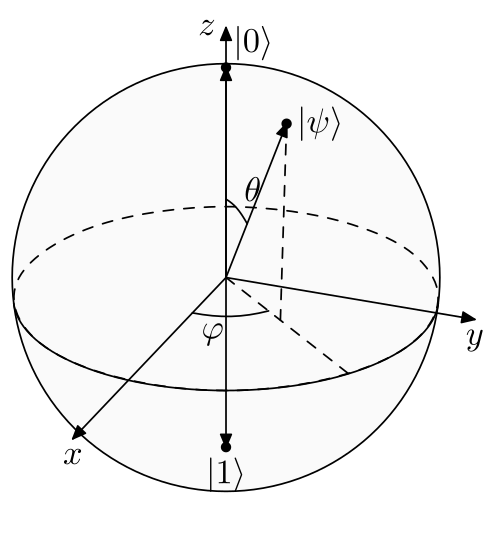

The Bloch sphere is a handy way to represent quantum states.


A quantum state can be written as a pair of coordinates $(\theta,\phi)$:

$$|\psi\rangle = \cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle,$$

with ${\theta,\phi} \in [0,\pi] \times [0,2\pi[$.

This applies to pure quantum states, which are points at the surface of the sphere. Mixed states, which are mixtures of pure states, are inside the sphere; but we will not talk about these.

The north and south poles of the Bloch sphere are the computational basis states, $|0\rangle$ and $|1\rangle$. Their coordinates are $(0,0)$ and  $(\pi,0)$ respectively. If we look at the cartesian coordinates, each coordinate is the expectation value of the Pauli observable associated with the axis. These expectations are $+1$ and $-1$ respectively for the computational basis states.

**What are the coordinates for the state $|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt 2}$?**



## 2.2 Precession phenomena

We will consider precession dynamics that are ubiquitous in quantum science. The description we consider here applies to many real world scenarios, including:
- Resonance frequency estimation
- Superconducting gate callibration
- Magnetic field sensing
- Quantum phase and amplitude estimation

We consider the action of the following Hamiltonian parametrized by $\omega$:

$$ H(\omega)=\frac{\omega}{2}\sigma_z,$$

which gives rise to the following time evolution operator:

$$ U = e^{-iHt} = \cos \left(\frac{\omega}{2}t \right)I+i\sin \left(\frac{\omega}{2}t \right)\sigma_z.$$

Suppose we apply this to an arbitrary initial state. We get the following time-dependent Bloch vector:

$$|\psi(t)\rangle = \frac{1}{\sqrt 2} \left( \cos (\theta_0/2)|0\rangle + e^{i(\phi_0 + \omega t)}\sin (\theta_0/2)|1\rangle\right) $$

I.e., the angle $\theta$ is fixed, while $\phi$ changes with time. This corresponds to an oscillation within a fixed horizontal plane.


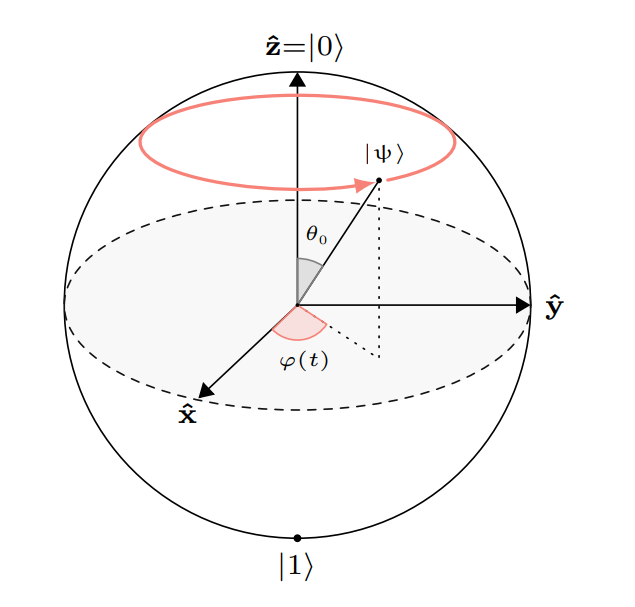

Let us consider the particular case where the initial state is $|+\rangle$. The state can again be written as a function of time:

$$|\psi(t)\rangle =  \cos \left(\frac{\omega }{2}t \right) |+\rangle + i\sin \left(\frac{\omega}{2}t \right)|-\rangle $$

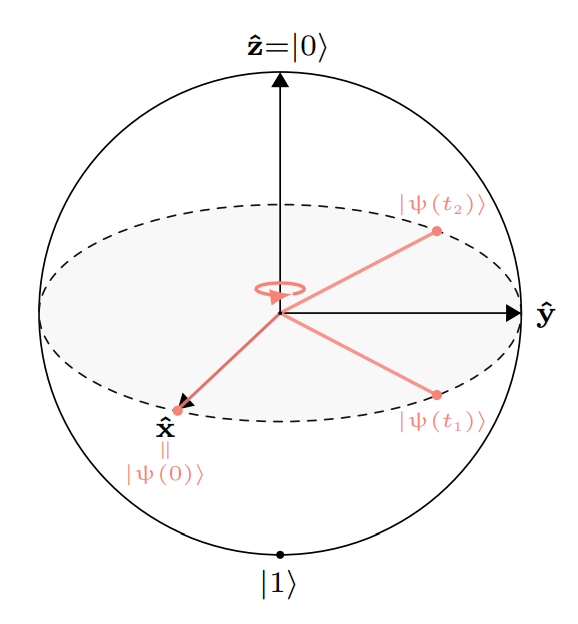

If we measure this state at an instant $t$ in the $x$-basis, the probability of measuring the eigenstate $|+\rangle$ is given by:

$$P(+\mid t) = \cos^2 \left(\frac{\omega}{2}t\right)$$

Estimating the precession frequency $\omega$ is important in many physical applications. The usual scenario is that we can choose the evolution time before measurement $t$; we make many such measurements and use the outcomes to estimate $\omega$.

Probability distributions like this arise in Rabi, Larmor and Ramsey phenomena.

## 2.3 Frequency estimation via curve fitting

Let us first generate and visualize some mock data generated according to the model above.

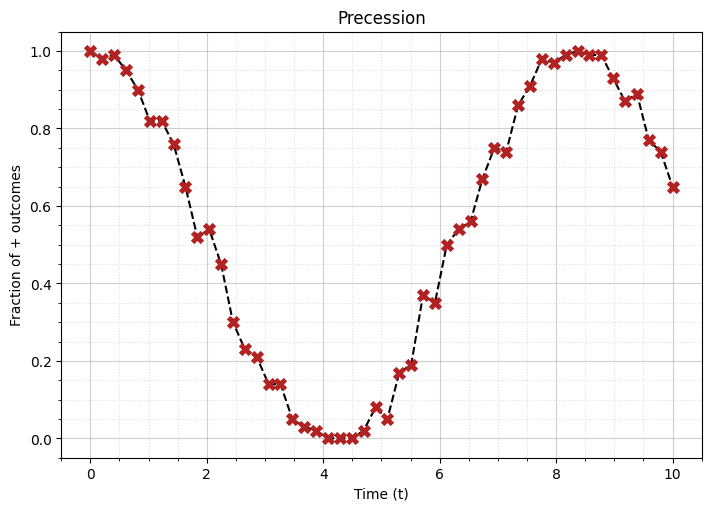

In [ ]:
def generate_data(w, ts, N):
  ts = np.array(ts)
  ps = np.cos(w*ts/2)**2
  D = np.random.binomial(N, ps)
  return D/N

def plot_data(ts, Ds, ref = None):
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    ax.set_title("Precession")
    if ref is not None:
      ax.plot(ts, ref, color="black", linestyle="--")
    else:
      ax.plot(ts, Ds, color="black", linestyle="--")

    ax.scatter(ts, Ds, marker="x",s=50, zorder = 2, linewidth=3.5, color="firebrick")

    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", alpha=0.6)
    ax.grid(which="minor", linestyle=":", alpha=0.4)

    ax.set_xlabel("Time (t)")
    ax.set_ylabel("Fraction of + outcomes")

    plt.show()

w = 0.75
N = 100
ts = np.linspace(0, 10, 50)
Ds = generate_data(w, ts, N)
plot_data(ts, Ds)

Now we want to discover $\omega$, which is determined by the frequency of this sinusoid.

**Find $\omega$ using the function `opt.curve_fit` from Scipy. Visualize the predictive power of your estimate by calculating its predictions `ys_pred` for the vector `ts`, and calling `plot_data(ts, Ds, ref = ys_pred)`.**

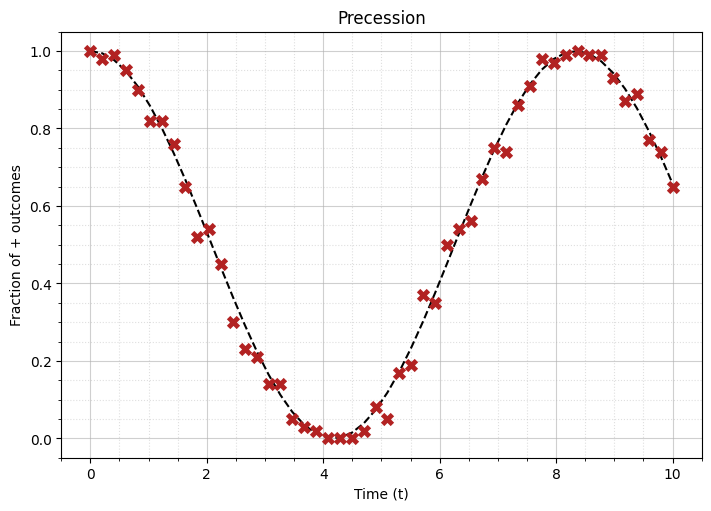

> Curve fit (generated data): estimated ω = 0.8.


In [ ]:
# Write your code below.

### Solution:
def prob(ts, w):
  return np.cos(w*ts/2)**2

def fit_estimate(ts, Ds, p0):
    r = opt.curve_fit(prob, ts, Ds, p0 = p0)
    wopt = r[0][0]
    pred = prob(ts, wopt)
    plot_data(ts, Ds, ref = pred)
    return wopt

w = fit_estimate(ts, Ds, p0 = 0.5)
print(f"> Curve fit (generated data): estimated ω = {w:.1f}.")

## 2.4 Curve fit for real world data

In practice, quantum systems are not so well behaved, nor is the data they produce. The file `IBM_dirp.data` contains measurement data obtained from one of IBM's quantum computers. It is the result of performing a Ramsey experiment on a superconducting qubit using pulse-level control. While the dynamics are very similar to the previous section, the data are not as regular. This can be clearly seen in the plot below.

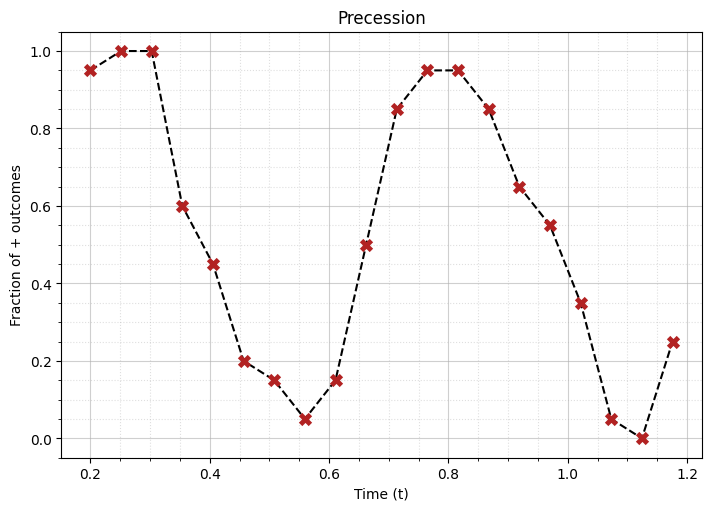

In [ ]:
with open('IBM_dirp.data', 'rb') as filehandle:
    xs, ys = pickle.load(filehandle)

plot_data(xs, ys)

**Try to apply the same strategy as before to fit these data.**

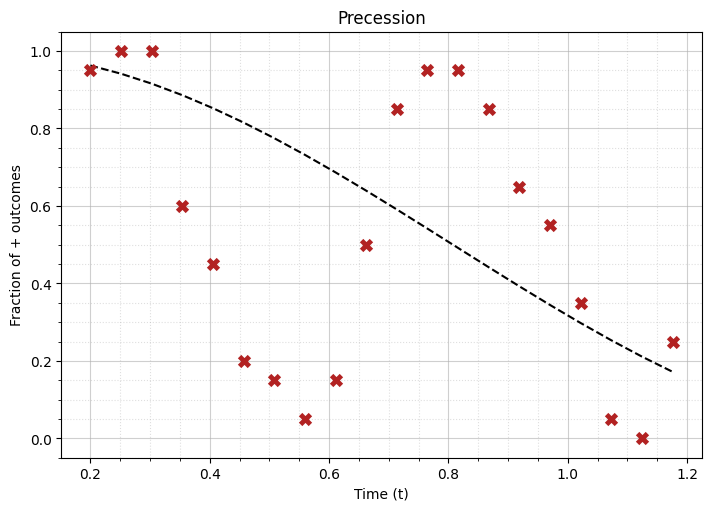

> Curve fit (real data): estimated ω = 1.9.


In [ ]:
# Write your code below.

### Solution:
def prob(ts, w):
  return np.cos(w*ts/2)**2

def fit_estimate(ts, Ds, p0):
    r = opt.curve_fit(prob, ts, Ds, p0 = p0)
    wopt = r[0][0]
    pred = prob(ts, wopt)
    plot_data(ts, Ds, ref = pred)
    return wopt

w = fit_estimate(xs, ys, p0 = None)
print(f"> Curve fit (real data): estimated ω = {w:.1f}.")

This may not have worked very well.

**Try to find a strategy that fits these data correctly.**

Everything is fair game. You may, for instance:
- Explore the options of `curve_fit`;
- Adapt the model;
- Use other functions/optimizers;
- ...

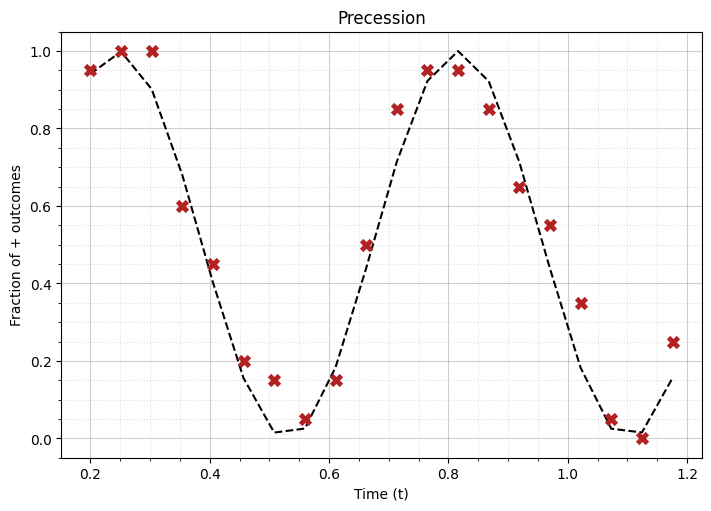

> Curve fit (real data): estimated ω = 11.0, B = -1.3.


In [ ]:
# Write your code below.

### Solution:
def prob2(ts, w, B):
  return np.cos(w*ts/2 + B)**2

def fit_estimate2(ts, Ds, p0):
    r = opt.curve_fit(prob2, ts, Ds, p0 = p0)
    popt = r[0]
    pred = prob2(ts, *popt)
    plot_data(ts, Ds, ref = pred)
    return popt

params = fit_estimate2(xs, ys, p0 = [7.5, 0])
print(f"> Curve fit (real data): estimated ω = {params[0]:.1f}, B = {params[1]:.1f}.")

## 2.5 Bayesian estimation (mock data)

Below is an implementation of Bayesian inference for this problem (mock data, as in section 2.3). It is very similar to the previous tutorial: the only change is the likelihood function, which now describes the generative model for the current example (precessing qubit).

Note the flexibility of this framework: unlike frequentist statistics, Bayesian inference direclty generalizes to this new likelihood, which has been augmented with dependence on a hyperparameter (the time $t$) in addition to the parameter of interest ($\omega$).

In [ ]:
ts2 = np.repeat(ts, N)
Ds2 = np.random.binomial(1, np.repeat(Ds, N))

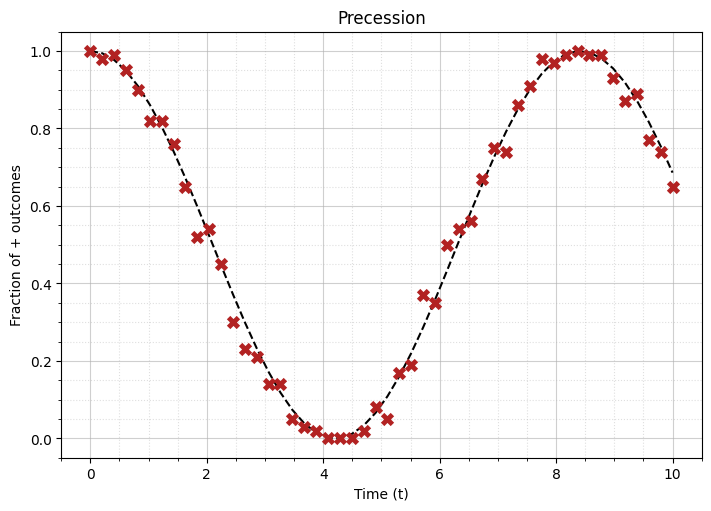

> Bayesian inference (generated data): estimated ω = 0.75.


In [ ]:
from scipy.special import logsumexp

def plot_likelihood(ps, Ls, log):
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    ax.set_title("Log-likelihood" if log else "Likelihood")
    ax.plot(ps, Ls, color="black")

    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", alpha=0.6)
    ax.grid(which="minor", linestyle=":", alpha=0.4)

    ax.set_xlabel("Value of $p_1$")
    ax.set_ylabel("Likelihood")

    plt.show()

def mu_std(xs, ws, return_std, log):
    if log:
        logZ = logsumexp(ws)
        ws = np.exp(ws - logZ)
    else:
        ws = ws/np.sum(ws)

    mu = np.sum(ws * xs)
    std = np.sqrt(np.sum(ws * (xs - mu)**2))
    if return_std:
        return mu, std
    return mu

def likelihood(ws, ts, ys, eps = 1e-10):
    args = np.outer(ws, ts) / 2.0
    p1s = np.cos(args) ** 2
    p1s = np.clip(p1s, eps, 1 - eps)
    Ls = np.sum(ys*np.log(p1s) + (1 - ys)*np.log1p(-p1s), axis=1)
    return Ls

def bayesian_estimate(xs, ys, domain, Npoints = int(1e3), log = True, plot = False, std = False):
    ws = np.linspace(domain[0],domain[1], Npoints)
    Ls = likelihood(ws, xs, ys)
    if plot:
        plot_likelihood(ws, Ls, log)
    return mu_std(ws, Ls, std, log)

r = bayesian_estimate(ts2, Ds2, domain = (0,1))
pred = prob(ts, r)
plot_data(ts, Ds, ref = pred)
print(f"> Bayesian inference (generated data): estimated ω = {r:.2f}.")

## 2.6 Advanced challenge: Bayesian estimation for real data

The following raw dataset is equivalent to `IBM_dirp.data`, but in the representation most convenient for Bayesian inference, similar to the `ts2` and `Ds2` in the previous section. The difference is that each datum corresponds to a single shot measurement, whereas in the  dataset `IBM_dirp.data` any $N$ measurements with the same time $t$ were grouped together into a tuple  $(t, \text{average of N outcomes})$.

For example (representing $+$ measurements as $1$):

`data = [(t=0, D=2/3)]`

`raw data = [(t=0, D=1), (t=0, D=0), (t=0, D=1)]`

The former format is more convenient for curve fiting, and the latter for Bayesian inference.

In [ ]:
with open('IBM_dirp_raw.data', 'rb') as filehandle:
    xs2, ys2 = pickle.load(filehandle)

**Fit these data using Bayesian inference.**

This is an optional advanced assignment. If interested, please **submit a report with your solution** by **Thursday, April 2nd**.

The report should be self-contained and take the form of a Jupyter notebook with a brief problem statement, functional code, and explanations of your approach. You can also include your failed attempts at solutions e.g. to discuss why they failed.

**Feel free to explore**¹, test out things that spike your curiosity, see how they work out, and discuss them! The format is purposefully very open.

Notes:
- Please join the dedicated Discord server for advanced assignments.
- The previous tutorials are helpful starting points, as well as the resources shared on Discord.
- Please don't use LLM generated code, or code you haven't written yourself. If you don't understand something enough to explain it, don't include it.  
- If you have any questions or comments or topics you'd like to discuss, feel free to reach out! I'm happy to take questions, both during our meetings or asynchronously on Discord.
- The report can also mention, if relevant, your failed attempts at solutions; for instance, to discuss why they failed. You can also include limitations, further directions you would like to explore, etc.
- Make sure the notebook runs correctly before sending, by doing `disconnect and delete runtime` followed by `run all` on Google Colab before downloading the file for submission. Please test this even if you run the code locally.
- You can send it either as a Google Colab link or as a .ipynb file. In the former case, please don't forget to turn on link sharing on Colab (toggle the option `everyone with the link can see the file`).

___________

¹Some interesting adjacent topics: integration methods for Bayesian inference, optimization methods for maximum likelihood estimation, different models, etc.